In [1]:
import uuid
import json
import datetime
from pathlib import Path
import streamlit as st
from langchain_core.messages import HumanMessage
from langgraph.types import Command
from langgraph.errors import GraphInterrupt
from dotenv import load_dotenv
load_dotenv()
from agent.graph import graph


d:\Projects\Planning Agent\agent\tools.py:11: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(


In [2]:

# ── Page config ───────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Planning Agent",
    page_icon="🗺️",
    layout="wide",
)

# ── Phase constants ───────────────────────────────────────────────────────────
# graph.py writes lowercase phase strings into state.
# app.py displays Title-case labels. _normalise_phase() bridges the two.
PHASE_ORDER = ["discovery", "alignment", "design", "refinement", "complete"]
PHASE_LABELS = {
    "discovery":  "Discovery",
    "alignment":  "Alignment",
    "design":     "Design",
    "refinement": "Refinement",
    "complete":   "Complete",
}
PHASE_ICONS = {
    "discovery":  "🔍",
    "alignment":  "🤝",
    "design":     "📐",
    "refinement": "✏️",
    "complete":   "✅",
}


def _normalise_phase(raw: str) -> str:
    """Accept any casing from graph state and return a canonical lowercase key."""
    return raw.strip().lower() if isinstance(raw, str) else "discovery"


def _phase_index(phase: str) -> int:
    """Safe PHASE_ORDER lookup — returns -1 if the value is not recognised."""
    try:
        return PHASE_ORDER.index(_normalise_phase(phase))
    except ValueError:
        return -1


# ── Sessions persistence ──────────────────────────────────────────────────────
SESSIONS_FILE = Path(__file__).parent / "sessions.json"


def _load_all_sessions() -> dict:
    if SESSIONS_FILE.exists():
        try:
            with open(SESSIONS_FILE, encoding="utf-8") as f:
                return json.load(f)
        except Exception:
            return {}
    return {}


def _save_all_sessions(sessions: dict):
    with open(SESSIONS_FILE, "w", encoding="utf-8") as f:
        json.dump(sessions, f, indent=2, ensure_ascii=False)


def _name_from_message(message: str) -> str:
    words = message.strip().split()
    return " ".join(words[:5]) if words else "Untitled"


def _save_current_session():
    tid = st.session_state.thread_id
    sessions = _load_all_sessions()
    existing = sessions.get(tid, {})
    name = existing.get("name", "")
    if not name:
        for msg in st.session_state.chat_history:
            if msg["role"] == "user":
                name = _name_from_message(msg["content"])
                break
    if not name:
        name = f"Session {tid[:8]}"
    sessions[tid] = {
        "name": name,
        "thread_id": tid,
        "chat_history": st.session_state.chat_history,
        "phase": st.session_state.phase,          # stored as lowercase
        "plan_draft": st.session_state.plan_draft,
        "approved": st.session_state.approved,
        "awaiting_resume": st.session_state.awaiting_resume,
        "updated_at": datetime.datetime.now().isoformat(),
    }
    _save_all_sessions(sessions)


def _switch_session(thread_id: str):
    sessions = _load_all_sessions()
    s = sessions.get(thread_id)
    if s:
        st.session_state.thread_id = s["thread_id"]
        st.session_state.chat_history = s["chat_history"]
        # Normalise phase coming from disk — old sessions may have Title-case values
        st.session_state.phase = _normalise_phase(s.get("phase", "discovery"))
        st.session_state.plan_draft = s.get("plan_draft")
        st.session_state.approved = s.get("approved", False)
        st.session_state.awaiting_resume = s.get("awaiting_resume", False)
    st.session_state.renaming_session = None
    st.rerun()


# ── Session state initialisation ──────────────────────────────────────────────
def _init_session():
    if "thread_id" not in st.session_state:
        st.session_state.thread_id = str(uuid.uuid4())
    if "chat_history" not in st.session_state:
        st.session_state.chat_history = []
    if "phase" not in st.session_state:
        st.session_state.phase = "discovery"       # lowercase to match graph.py
    if "plan_draft" not in st.session_state:
        st.session_state.plan_draft = None
    if "awaiting_resume" not in st.session_state:
        st.session_state.awaiting_resume = False
    if "approved" not in st.session_state:
        st.session_state.approved = False
    if "renaming_session" not in st.session_state:
        st.session_state.renaming_session = None

_init_session()

# ── Helpers ───────────────────────────────────────────────────────────────────
def _get_config() -> dict:
    return {"configurable": {"thread_id": st.session_state.thread_id}}


def _sync_state_from_graph():
    """Pull the latest phase / plan / approved flag out of the graph checkpoint."""
    try:
        snapshot = graph.get_state(_get_config())
        if snapshot and snapshot.values:
            raw_phase = snapshot.values.get("phase", st.session_state.phase)
            st.session_state.phase = _normalise_phase(raw_phase)

            plan = snapshot.values.get("plan_draft")
            if plan:
                st.session_state.plan_draft = plan

            if snapshot.values.get("approved"):
                st.session_state.approved = True
                st.session_state.phase = "complete"
    except Exception:
        pass


def _run_graph(user_message: str) -> str:
    config = _get_config()
    label = PHASE_LABELS.get(st.session_state.phase, st.session_state.phase.title())

    with st.spinner(f"Agent working — {label} phase..."):
        try:
            if st.session_state.awaiting_resume:
                snapshot = graph.get_state(config)
                if not snapshot or not snapshot.values:
                    # Checkpoint lost — restart cleanly
                    st.session_state.awaiting_resume = False
                    result = graph.invoke(
                        {"messages": [HumanMessage(content=user_message)]},
                        config=config,
                    )
                else:
                    result = graph.invoke(Command(resume=user_message), config=config)
            else:
                result = graph.invoke(
                    {"messages": [HumanMessage(content=user_message)]},
                    config=config,
                )

            st.session_state.awaiting_resume = False
            _sync_state_from_graph()

            messages = result.get("messages", [])
            for msg in reversed(messages):
                if hasattr(msg, "content") and not isinstance(msg, HumanMessage):
                    return msg.content
            return result.get("final_plan") or result.get("plan_draft") or "Done."

        except GraphInterrupt as exc:
            st.session_state.awaiting_resume = True
            _sync_state_from_graph()
            interrupted_value = exc.args[0] if exc.args else ""
            return str(interrupted_value)

        except Exception as exc:
            st.session_state.awaiting_resume = False
            return f"⚠️ Error: {exc}"


def _new_session():
    for key in ["thread_id", "chat_history", "phase", "plan_draft", "awaiting_resume", "approved"]:
        st.session_state.pop(key, None)
    st.session_state.renaming_session = None
    _init_session()
    st.rerun()


# ── Sidebar ───────────────────────────────────────────────────────────────────
with st.sidebar:
    st.title("Planning Agent")
    st.caption("A multi-phase planning assistant powered by LLMs and LangGraph.")

    st.divider()

    # Phase progress — compare using _phase_index so casing never matters
    st.subheader("Phase")
    current_phase = _normalise_phase(st.session_state.phase)
    current_idx = _phase_index(current_phase)

    for phase_key in PHASE_ORDER:
        icon  = PHASE_ICONS[phase_key]
        label = PHASE_LABELS[phase_key]
        idx   = _phase_index(phase_key)

        if phase_key == current_phase:
            st.markdown(f"**→ {icon} {label}**")
        elif idx < current_idx:
            st.markdown(f"~~{icon} {label}~~")
        else:
            st.markdown(f"{icon} {label}")

    st.divider()

    if st.button("➕ New Session", use_container_width=True):
        _new_session()

    st.divider()

    # Past sessions
    st.subheader("Sessions")
    all_sessions = _load_all_sessions()
    sorted_sessions = sorted(
        all_sessions.values(),
        key=lambda s: s.get("updated_at", ""),
        reverse=True,
    )

    if not sorted_sessions:
        st.caption("No saved sessions yet.")
    else:
        for s in sorted_sessions:
            tid = s["thread_id"]
            name = s.get("name") or f"Session {tid[:8]}"
            is_active = tid == st.session_state.thread_id

            if st.session_state.renaming_session == tid:
                new_name = st.text_input(
                    "New name",
                    value=name,
                    key=f"rename_input_{tid}",
                    label_visibility="collapsed",
                )
                save_col, cancel_col = st.columns(2)
                with save_col:
                    if st.button("✔ Save", key=f"save_rename_{tid}", use_container_width=True):
                        sessions = _load_all_sessions()
                        if tid in sessions:
                            sessions[tid]["name"] = new_name.strip() or name
                            _save_all_sessions(sessions)
                        st.session_state.renaming_session = None
                        st.rerun()
                with cancel_col:
                    if st.button("✖ Cancel", key=f"cancel_rename_{tid}", use_container_width=True):
                        st.session_state.renaming_session = None
                        st.rerun()
            else:
                label_str = f"**› {name}**" if is_active else name
                btn_col, edit_col, del_col = st.columns([5, 1, 1])
                with btn_col:
                    if st.button(label_str, key=f"session_{tid}", use_container_width=True):
                        if not is_active:
                            _switch_session(tid)
                with edit_col:
                    if st.button("✏️", key=f"rename_{tid}", help="Rename", use_container_width=True):
                        st.session_state.renaming_session = tid
                        st.rerun()
                with del_col:
                    if st.button("🗑️", key=f"delete_{tid}", help="Delete", use_container_width=True):
                        sessions = _load_all_sessions()
                        sessions.pop(tid, None)
                        _save_all_sessions(sessions)
                        if is_active:
                            _new_session()
                        else:
                            st.rerun()

    if st.session_state.approved:
        st.divider()
        st.success("Plan approved!")

# ── Main layout ───────────────────────────────────────────────────────────────
chat_col, plan_col = st.columns([6, 4])

# ── Left column: Chat ─────────────────────────────────────────────────────────
with chat_col:
    st.header("Chat")

    for msg in st.session_state.chat_history:
        with st.chat_message(msg["role"]):
            st.markdown(msg["content"])

    if st.session_state.approved:
        st.info("The plan has been approved. Start a new session to plan something else.")
    else:
        placeholder = (
            "Reply to the agent..." if st.session_state.awaiting_resume
            else "Describe what you want to plan..."
        )
        user_input = st.chat_input(placeholder)

        if user_input:
            st.session_state.chat_history.append({"role": "user", "content": user_input})
            with st.chat_message("user"):
                st.markdown(user_input)

            agent_response = _run_graph(user_input)

            st.session_state.chat_history.append({"role": "assistant", "content": agent_response})
            with st.chat_message("assistant"):
                st.markdown(agent_response)

            _save_current_session()

            if st.session_state.phase in ("design", "refinement", "complete"):
                _sync_state_from_graph()

            st.rerun()

# ── Right column: Plan preview ────────────────────────────────────────────────
with plan_col:
    st.header("Plan Preview")

    if st.session_state.plan_draft:
        st.markdown(st.session_state.plan_draft)

        st.divider()

        if st.session_state.phase in ("design", "refinement") and not st.session_state.approved:
            btn_col1, btn_col2 = st.columns(2)

            with btn_col1:
                if st.button("✅ Approve Plan", use_container_width=True, type="primary"):
                    approval_response = _run_graph("Approved")
                    st.session_state.chat_history.append({"role": "user", "content": "Approved"})
                    st.session_state.chat_history.append({"role": "assistant", "content": approval_response})
                    _save_current_session()
                    _sync_state_from_graph()
                    st.rerun()

            with btn_col2:
                if st.button("✏️ Request Changes", use_container_width=True):
                    st.session_state.chat_history.append(
                        {"role": "assistant", "content": "What changes would you like to make to the plan?"}
                    )
                    st.rerun()
    else:
        st.info("The plan will appear here once the Design phase is complete.")

2026-06-28 22:35:36.305 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


NameError: name '__file__' is not defined

In [3]:
# agent package
from agent.state import PlannerState, FeedbackClassification
from agent.tools import tools
from agent.formatter import save_plan, format_plan, PLAN_TEMPLATE
from agent.graph import graph

__all__ = [
    "PlannerState",
    "FeedbackClassification",
    "tools",
    "save_plan",
    "format_plan",
    "PLAN_TEMPLATE",
    "graph",
]


In [4]:
from typing import Annotated, List, Optional, Literal
from pydantic import BaseModel, Field
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage


class PlannerState(TypedDict):
    topic: str
    messages: Annotated[List[BaseMessage], add_messages]  # full chat history, auto-appended
    phase: str                                             # discovery | alignment | design | refinement | complete
    research_summary: Optional[str]                       # output of Discovery phase
    clarifying_questions: List[str]                       # questions generated in Alignment phase
    user_answers: List[str]                               # user responses to clarifying questions
    tool_outputs: List[str]                               # raw tool call results
    plan_draft: Optional[str]                             # working plan Markdown (Design phase)
    final_plan: Optional[str]                             # approved plan Markdown
    approved: Optional[bool]                              # True once user approves the plan
    refinement_action: Optional[str]                      # approve | revise | question | alternative
    display_content: Optional[str]                        # content shown by present_plan node

class RouterDecision(BaseModel):
    need_clarification: bool
    clarifying_questions: List[str]
    user_answers: List[str]
    max_questions: int

class Task(BaseModel):
    id: int
    title: str
    goal: str = Field(..., description="One sentence describing what reader should do/understand")
    bullets: List[str] = Field(..., min_length=3, max_length=6)
    target_words: int = Field(..., description="Target words (120-550).")
    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_code: bool = False

class FeedbackClassification(BaseModel):
    feedback_type: Literal["revision", "question", "alternative", "approval"]
    updated_plan: Optional[str] = None  # populated for "revision"
    answer: Optional[str] = None        # populated for "question"



In [5]:
import os
from pathlib import Path

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.tools import tool


# ── Web Search (Tavily) ──────────────────────────────────────────────────────
tavily_search = TavilySearchResults(
    max_results=5,
    description=(
        "Search the web for current best practices, libraries, tutorials, and "
        "real-world examples relevant to the research topic."
    ),
)


# ── Wikipedia ────────────────────────────────────────────────────────────────
_wiki_wrapper = WikipediaAPIWrapper(top_k_results=3, doc_content_chars_max=3000)
wikipedia = WikipediaQueryRun(
    api_wrapper=_wiki_wrapper,
    description=(
        "Look up foundational concepts, definitions, and background knowledge "
        "about a topic on Wikipedia."
    ),
)


# ── Local File Reader ─────────────────────────────────────────────────────────
_WORKSPACE_ROOT = Path(os.getenv("WORKSPACE_ROOT", ".")).resolve()


@tool
def read_file_tool(file_path: str) -> str:
    """Read the contents of a local file for code-aware planning.

    Args:
        file_path: Path to the file, relative to the workspace root.

    Returns:
        File contents as a string, or an error message if unreadable.
    """
    try:
        target = (_WORKSPACE_ROOT / file_path).resolve()
        # Prevent path traversal outside the workspace root
        target.relative_to(_WORKSPACE_ROOT)
        return target.read_text(encoding="utf-8")
    except ValueError:
        return "Error: Access denied — path is outside the workspace root."
    except FileNotFoundError:
        return f"Error: File not found — '{file_path}'"
    except OSError as exc:
        return f"Error reading file: {exc}"


# ── Tool registry (passed to LangGraph ToolNode) ─────────────────────────────
tools: list = [tavily_search, wikipedia, read_file_tool]


In [6]:
from pathlib import Path
import time


def save_plan(content: str) -> str:
    """
    Save the plan content to a Markdown file in the 'plans' directory.
    Returns the path to the saved file.
    """
    plans_dir = Path("plans")
    plans_dir.mkdir(parents=True, exist_ok=True)
    plan_path = plans_dir / f"plan_{time.strftime('%Y%m%d_%H%M%S')}.md"
    plan_path.write_text(content, encoding="utf-8")
    return str(plan_path)


# ── Plan template ─────────────────────────────────────────────────────────────
# Mirrors the exact structure demanded by design_prompt.
# Import this into prompts.py or inject it into the design prompt so the LLM
# always produces a consistently structured document.
PLAN_TEMPLATE = """\
## Plan: {title}

### TL;DR
{tldr}

### Steps

**Phase 1 — {phase_1_name}**
1. {step} — `{file_or_command}` *(parallel)*
2. {step}

**Phase 2 — {phase_2_name}**
3. {step}

### Relevant Files & References
- `path/to/file.py` — {reason}

### Verification
1. {command_or_check}
2. {command_or_check}

### Decisions
- **{decision_title}**: Chose X over Y because {reason}.

### Scope Exclusions
- {exclusion}

### Further Considerations
1. {consideration}
"""


def format_plan(
    title: str,
    tldr: str,
    steps: list[str],
    files: list[str],
    verification: list[str],
    decisions: list[str],
    exclusions: list[str],
    considerations: list[str],
) -> str:
    """
    Programmatically build a plan string from structured components.
    Useful when you want to assemble the plan from typed data rather than
    relying on raw LLM text.

    Each list item should be a plain string (no leading '- ' or numbering needed).
    """
    def _bullets(items: list[str]) -> str:
        return "\n".join(f"- {item}" for item in items) if items else "- N/A"

    def _numbered(items: list[str]) -> str:
        return "\n".join(f"{i + 1}. {item}" for i, item in enumerate(items)) if items else "1. N/A"

    plan = f"## Plan: {title}\n\n"
    plan += f"### TL;DR\n{tldr}\n\n"
    plan += f"### Steps\n{_numbered(steps)}\n\n"
    plan += f"### Relevant Files & References\n{_bullets(files)}\n\n"
    plan += f"### Verification\n{_numbered(verification)}\n\n"
    plan += f"### Decisions\n{_bullets(decisions)}\n\n"
    plan += f"### Scope Exclusions\n{_bullets(exclusions)}\n\n"
    plan += f"### Further Considerations\n{_numbered(considerations)}\n"
    return plan

In [7]:
discovery_prompt = """You are a research agent in Phase 1 (Discovery) of a planning pipeline.

Your sole job is to gather rich, factual context about the user's topic BEFORE any planning begins.
You must NOT ask the user questions, make assumptions, or produce a plan — only research.

## Instructions
1. Decompose the topic into independent research areas (e.g., frontend, backend, auth, deployment).
2. For each area, invoke the available tools in parallel:
   - Use `tavily_search` for current best practices, libraries, and real-world examples.
   - Use `wikipedia` for foundational concepts and definitions.
   - Use `read_file` if the user references local files or an existing codebase.
3. Cross-verify facts across sources. If two sources conflict, note both.
4. Stop calling tools once you have sufficient depth — do not over-search.

## Output Format
Return a structured research summary with these sections:

**Key Facts & Concepts**
- Bullet list of verified facts directly relevant to the topic.

**Patterns & Best Practices**
- Common architectural patterns, library choices, or design approaches found in research.

**Analogous Examples**
- Real-world systems or open-source projects that solve a similar problem.

**Potential Blockers & Risks**
- Technical constraints, known pitfalls, or common failure points discovered in research.

**Open Questions** (for Alignment phase)
- Specific gaps in information that ONLY the user can resolve (scope, preferences, constraints).

Do not produce a plan. Do not ask the user anything yet."""

alignment_prompt = """You are a clarification agent in Phase 2 (Alignment) of a planning pipeline.

You have received a research summary from the Discovery phase.
Your job is to identify the minimal set of questions that, if answered, would unlock a precise, actionable plan.

## Rules
- You have exactly ONE round to ask questions. Ask everything critical now — there is no follow-up round.
- Discard questions that can be reasonably inferred or that don't affect the plan's structure.
- For each question, provide 2–4 concrete options as a numbered list where possible.
- Always include a "Skip / No preference" option for every question so the user can move on quickly.
- Ask at most 4 questions total. Fewer is better.
- If you already have enough information to design a precise plan, reply with exactly: PROCEED_TO_DESIGN

## Output Format

Ask your questions in this exact structure:

---
**Before I build your plan, I have a few quick questions:**

**Q1: [Short question title]**
[One-sentence context explaining why this matters]
1. Option A
2. Option B
3. Option C
4. Skip / No preference

**Q2: [Short question title]**
...
---

Do not summarize the research. Do not start planning yet. Only ask questions."""

design_prompt = """You are a planning agent in Phase 3 (Design) of a planning pipeline.

You have received the research summary (Discovery) and the user's answers to clarifying questions (Alignment).
Your job is to produce one complete, structured, actionable plan document.

## Instructions
1. Every step must be concrete and independently actionable — no vague steps like "set up the project".
2. Mark dependencies explicitly: steps that can run in parallel should be labeled **(parallel)**, sequential steps should be clearly ordered.
3. Group steps into named phases if there are 5 or more steps.
4. Reference specific files, functions, libraries, or commands where known.
5. Include verification steps — how to confirm each phase is working correctly.
6. Document decisions made and why, including options that were considered but excluded.
7. Limit "Further Considerations" to a maximum of 3 items — things genuinely worth noting but out of current scope.

## Output Format — use this EXACT structure:

---
## Plan: {Concise Title}

### TL;DR
{2-3 sentences: what is being built, the core approach, and the primary constraint or goal.}

### Steps

**Phase 1 — {Name}**
1. {Step} — {file or command if applicable} *(parallel)*
2. {Step} — {file or command if applicable}

**Phase 2 — {Name}**
3. {Step}
...

### Relevant Files & References
- `path/to/file.py` — {reason it is relevant, function or pattern to reuse}

### Verification
1. {Command or manual check to verify Phase 1 is complete}
2. {Command or manual check to verify Phase 2 is complete}

### Decisions
- **{Decision title}**: Chose X over Y because {reason}.

### Scope Exclusions
- {Feature or concern explicitly out of scope, and why.}

### Further Considerations
1. {Optional future improvement or open risk — max 3 items}
---

Do not implement anything. Do not write code. Output only the plan document."""

refinement_prompt = """You are a planning agent in Phase 4 (Refinement) of a planning pipeline.

You have presented a plan to the user and received their feedback.
Your job is to classify the feedback and respond according to its type.

## Feedback Classification

Classify the feedback as exactly one of:
- **revision**: The user wants to change, add, or remove something.
- **question**: The user is asking for clarification about the plan.
- **alternative**: The user wants a fundamentally different approach.
- **approval**: The user is satisfied with the plan.

## Instructions by Type

**revision**:
- Apply the change surgically. Do not rewrite unaffected sections.
- Produce the FULL updated plan using the same structure as the Design phase.
- Add a brief **"Changes Made"** section at the top listing what was revised.
- Put the complete updated plan text in the `updated_plan` field.

**question**:
- Answer the user's question concisely.
- Put the full answer text in the `answer` field.
- Do NOT put anything in `updated_plan`.

**alternative**:
- Set feedback_type to "alternative". Leave `updated_plan` and `answer` empty.
- The system will automatically restart Discovery.

**approval**:
- Set feedback_type to "approval". Leave `updated_plan` and `answer` empty.

## Rules
- Never implement, write code, or execute steps.
- Never discard sections the user did not ask to change.
- Keep the plan format identical to the Design phase output."""

In [8]:
from __future__ import annotations
import sqlite3
from pathlib import Path
from typing import Literal

from dotenv import load_dotenv
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.types import interrupt



from agent.formatter import save_plan
from agent.prompts import (
    alignment_prompt,
    design_prompt,
    discovery_prompt,
    refinement_prompt,
)
from agent.state import FeedbackClassification, PlannerState
from agent.tools import tools

load_dotenv()

# ── LLM instances ─────────────────────────────────────────────────────────────
_discovery_llm = ChatOpenAI(model="gpt-4o", temperature=0).bind_tools(tools)
_alignment_llm = ChatOpenAI(model="gpt-4o", temperature=0.2)
_design_llm = ChatOpenAI(model="gpt-4o", temperature=0.4)
_refinement_llm = ChatOpenAI(model="gpt-4o", temperature=0.2).with_structured_output(
    FeedbackClassification
)


# ── Node: discovery ───────────────────────────────────────────────────────────
def discovery(state: PlannerState) -> dict:
    """
    Phase 1 — Silent ReAct research loop.

    Runs entirely in the background with no interrupts and no output shown to the
    user. When the LLM stops calling tools it stores the research summary and
    advances phase to 'alignment'.
    """
    messages = list(state["messages"])

    # Prepend the system prompt on the very first call only.
    if not messages or not isinstance(messages[0], SystemMessage):
        messages = [SystemMessage(content=discovery_prompt)] + messages

    response: AIMessage = _discovery_llm.invoke(messages)
    updates: dict = {"messages": [response]}

    if not response.tool_calls:
        updates["research_summary"] = response.content
        updates["phase"] = "alignment"

    return updates


# ── Node: tool_executor ───────────────────────────────────────────────────────
tool_executor = ToolNode(tools, handle_tool_errors=True)


def _route_discovery(state: PlannerState) -> Literal["tool_executor", "alignment"]:
    last = state["messages"][-1]
    if isinstance(last, AIMessage) and last.tool_calls:
        return "tool_executor"
    return "alignment"


# ── Node: alignment ───────────────────────────────────────────────────────────
def alignment(state: PlannerState) -> dict:
    """
    Phase 2 — Ask ONE round of clarifying questions (each with a skip option).

    If the LLM already has enough context it returns PROCEED_TO_DESIGN and we
    skip the interrupt entirely. Otherwise we pause once for the user's answers
    and immediately advance to design — no second round.
    """
    research = state.get("research_summary", "")

    messages = [
        SystemMessage(content=alignment_prompt),
        HumanMessage(content=f"Research summary:\n\n{research}"),
    ]

    try:
        response: AIMessage = _alignment_llm.invoke(messages)
        questions_text = (response.content or "").strip()
    except Exception:
        return {
            "clarifying_questions": [],
            "user_answers": [],
            "phase": "design",
        }

    # LLM decided it has enough info — skip the interrupt
    if "PROCEED_TO_DESIGN" in questions_text.upper():
        return {
            "messages": [response],
            "clarifying_questions": [],
            "user_answers": [],
            "phase": "design",
        }

    # Single interrupt: ask questions, collect answers, advance to design
    user_answer: str = interrupt(questions_text)

    return {
        "messages": [response],
        "clarifying_questions": [questions_text],
        "user_answers": [user_answer],
        "phase": "design",
    }


# ── Node: design ──────────────────────────────────────────────────────────────
def design(state: PlannerState) -> dict:
    """
    Phase 3 — Generate the plan and commit it to state.

    No interrupt here. plan_draft is written to state before present_plan runs,
    so the Plan Preview panel in the UI can read it from the checkpoint snapshot
    while the user is being asked for feedback.
    """
    messages = [
        SystemMessage(content=design_prompt),
        HumanMessage(content=f"Research summary:\n\n{state.get('research_summary', '')}"),
        HumanMessage(
            content=f"Clarifying answers from user:\n\n{state.get('user_answers', [])}"
        ),
    ]

    try:
        response: AIMessage = _design_llm.invoke(messages)
        plan_draft = response.content
    except Exception as exc:
        plan_draft = _fallback_plan(state, str(exc))

    save_plan(plan_draft)

    return {
        "plan_draft": plan_draft,
        "phase": "refinement",
        "refinement_action": None,   # reset so present_plan → refinement is a clean entry
        "display_content": plan_draft,  # picked up by present_plan
    }


def _fallback_plan(state: PlannerState, error_hint: str) -> str:
    research = state.get("research_summary", "No research available.")
    answers = state.get("user_answers", [])
    answers_str = "\n".join(f"- {a}" for a in answers) if answers else "None provided."
    return (
        "## Plan (fallback — LLM unavailable)\n\n"
        f"**Error:** {error_hint[:200]}\n\n"
        "### Research Summary\n"
        f"{research}\n\n"
        "### User Clarifications\n"
        f"{answers_str}\n\n"
        "### Suggested Next Steps\n"
        "1. Review the research summary above.\n"
        "2. Incorporate the clarifications from the alignment phase.\n"
        "3. Proceed with implementation iteratively.\n"
    )


# ── Node: present_plan ────────────────────────────────────────────────────────
def present_plan(state: PlannerState) -> dict:
    """
    Single-responsibility presentation node — the ONLY place that interrupts.

    Shows display_content (or plan_draft as fallback) to the user, collects
    their response, and stores it as a HumanMessage for refinement to classify.
    display_content is cleared after use so it isn't re-shown on the next pass.
    """
    content = state.get("display_content") or state.get("plan_draft", "No plan available yet.")
    user_input: str = interrupt(content)
    return {
        "messages": [HumanMessage(content=user_input)],
        "display_content": None,
    }


def _route_after_present_plan(
    state: PlannerState,
) -> Literal["refinement", "discovery"]:
    """
    Route to discovery when an alternative restart was confirmed by the user,
    otherwise always route to refinement for feedback classification.
    """
    if state.get("phase") == "discovery":
        return "discovery"
    return "refinement"


# ── Node: refinement ─────────────────────────────────────────────────────────
def refinement(state: PlannerState) -> dict:
    """
    Phase 4 — Classify user feedback with structured output and update state.

    No interrupts here; all user interaction is handled by present_plan.
    Writes refinement_action and (where needed) display_content so that
    _route_refinement and present_plan know what to show next.
    """
    plan_draft = state.get("plan_draft", "")
    user_feedback = state["messages"][-1].content

    messages = [
        SystemMessage(content=refinement_prompt),
        HumanMessage(content=f"Current plan:\n\n{plan_draft}"),
        HumanMessage(content=f"User feedback:\n\n{user_feedback}"),
    ]

    try:
        result: FeedbackClassification = _refinement_llm.invoke(messages)
        feedback_type = result.feedback_type
    except Exception:
        return {
            "refinement_action": "question",
            "display_content": (
                "I had trouble understanding your feedback. Could you rephrase it?\n\n"
                "(e.g. 'Approved', 'Change X to Y', or 'Try a completely different approach')"
            ),
        }

    if feedback_type == "approval":
        return {
            "messages": [AIMessage(content=(
                "Plan approved. You can now hand this off to an implementation agent "
                "or proceed step by step. The plan has been saved."
            ))],
            "approved": True,
            "final_plan": plan_draft,
            "phase": "complete",
            "refinement_action": "approve",
        }

    if feedback_type == "revision":
        updated_plan = result.updated_plan or plan_draft
        save_plan(updated_plan)
        return {
            "plan_draft": updated_plan,
            "phase": "refinement",
            "refinement_action": "revise",
            "display_content": updated_plan,
        }

    if feedback_type == "question":
        answer = result.answer or "I don't have more details on that."
        return {
            "phase": "refinement",
            "refinement_action": "question",
            "display_content": answer,
        }

    if feedback_type == "alternative":
        return {
            "phase": "discovery",
            "research_summary": None,
            "plan_draft": None,
            "clarifying_questions": [],
            "user_answers": [],
            "refinement_action": "alternative",
            "display_content": (
                "Got it — I'll restart research with a new direction.\n\n"
                "Please confirm or describe what you'd like to focus on instead."
            ),
        }

    # Fallback
    return {
        "refinement_action": "question",
        "display_content": "I didn't understand your feedback. Please rephrase.",
    }


def _route_refinement(
    state: PlannerState,
) -> Literal["present_plan", "__end__"]:
    if state.get("refinement_action") == "approve":
        return END
    return "present_plan"


In [10]:


# ── Graph assembly ────────────────────────────────────────────────────────────
def build_graph():
    builder = StateGraph(PlannerState)

    builder.add_node("discovery", discovery)
    builder.add_node("tool_executor", tool_executor)
    builder.add_node("alignment", alignment)
    builder.add_node("design", design)
    builder.add_node("present_plan", present_plan)
    builder.add_node("refinement", refinement)

    # Entry
    builder.add_edge(START, "discovery")

    # Discovery ReAct loop: tool calls feed back; final text → alignment
    builder.add_conditional_edges(
        "discovery",
        _route_discovery,
        {"tool_executor": "tool_executor", "alignment": "alignment"},
    )
    builder.add_edge("tool_executor", "discovery")

    # Alignment always produces one round then flows straight to design (no loop)
    builder.add_edge("alignment", "design")

    # Design commits plan_draft to state, then present_plan shows it to the user
    builder.add_edge("design", "present_plan")

    # After user input: route to refinement or restart discovery (alternative path)
    builder.add_conditional_edges(
        "present_plan",
        _route_after_present_plan,
        {"refinement": "refinement", "discovery": "discovery"},
    )

    # Refinement: approve → END, everything else → show updated content via present_plan
    builder.add_conditional_edges(
        "refinement",
        _route_refinement,
        {"present_plan": "present_plan", END: END},
    )

    # Persistence
    db_path = Path(".").parent.parent / "checkpoints.db"
    #db_path = Path(__file__).parent.parent / "checkpoints.db"
    conn = sqlite3.connect(str(db_path), check_same_thread=False)
    checkpointer = SqliteSaver(conn)

    return builder.compile(checkpointer=checkpointer)


graph = build_graph()

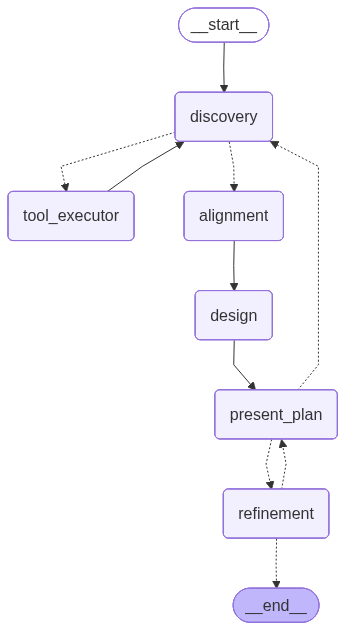

In [11]:
graph

In [ ]:
import subprocess
import sys


def main():
    subprocess.run(
        [sys.executable, "-m", "streamlit", "run", "app.py"],
        check=True,
    )


if __name__ == "__main__":
    main()
